<a href="https://colab.research.google.com/github/acastellanos-ie/NLP-MBDS-EN/blob/main/06_transfer_learning_and_fine_tuning/transfer_learning_and_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning for Text Classification

A pretrained language model already contains useful representations of language, but it has not been trained to solve every task we care about. Transfer learning asks how we can adapt that general knowledge to a specific problem without starting from zero.

Our task is to classify tweets as reports of a real disaster or not. We will begin with a strong lexical baseline and then fine-tune DistilBERT on exactly the same examples. Keeping the data split and evaluation fixed is what turns this into a useful comparison rather than a list of unrelated scores.

The practice is organised in six stages:

1. Prepare the data and create one fixed split.
2. Train a TF-IDF lexical baseline.
3. Fine-tune DistilBERT on the same tweets.
4. Inspect the errors and controlled stress cases hidden by the headline metrics.
5. Use an instruction-tuned model zero-shot, without disaster-tweet training labels.
6. Optionally call a GPT model through an online API on the same stress cases.


In [ ]:
# @title Setup
%pip install -q "requests==2.32.4" "pandas==2.2.2" "scikit-learn==1.7.1" "matplotlib==3.10.5" "seaborn==0.13.2" "transformers==5.16.1" "sentencepiece==0.2.1" "openai>=1.66.0,<3.0.0"

import logging
import os
import warnings
from pathlib import Path

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", message=r"(?s).*HF_TOKEN.*")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("torchao").setLevel(logging.ERROR)
from transformers.utils import logging as transformers_logging
transformers_logging.set_verbosity_error()

repo_path = Path("/content/NLP-MBDS-EN")
if Path("/content").exists() and not repo_path.exists():
    !git clone -q https://github.com/acastellanos-ie/NLP-MBDS-EN.git /content/NLP-MBDS-EN

# Stage 1: Data and preprocessing

## Load the data

A fair model comparison starts with the data, not with the model. The files come from Kaggle's [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started) competition. The labelled file contains 7,613 tweets. Kaggle also provides a separate test file, but it has no target column, so it cannot tell us how well a model works.

We will create one validation set from the labelled data and leave it untouched during training. Every supervised model will be evaluated on those same rows.

In [2]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
from IPython.display import display

candidate_data_dirs = [
    Path("data"),
    Path("06_transfer_learning_and_fine_tuning/data"),
    Path("/content/NLP-MBDS-EN/06_transfer_learning_and_fine_tuning/data"),
]
data_dir = next(
    (path for path in candidate_data_dirs if (path / "train.csv").exists()),
    None,
)
if data_dir is None:
    raise FileNotFoundError("Could not find train.csv. Run the setup cell first.")

training_df = pd.read_csv(data_dir / "train.csv")
test_df = pd.read_csv(data_dir / "test.csv")

print(f"Labelled rows: {len(training_df):,}")
print(f"Unlabelled test rows: {len(test_df):,}")
display(training_df[["text", "target"]].head(4))

Labelled rows: 7,613
Unlabelled test rows: 3,263


,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1


The first four rows are all disasters because the file is ordered; they are not a representative sample. This is one reason to shuffle when we create the split. The unlabelled test set is useful for a final Kaggle submission, but using it here would produce predictions without an evaluation.

## Check the labels and repeated text

Before modelling, let’s check class balance, missing values and duplicate text.

In [3]:
class_summary = (
    training_df["target"]
    .value_counts()
    .sort_index()
    .rename(index={0: "not disaster", 1: "disaster"})
    .to_frame("rows")
)
class_summary["share"] = class_summary["rows"] / len(training_df)

duplicate_after_first = training_df.duplicated("text").sum()
repeated_mask = training_df.duplicated("text", keep=False)
conflicting_texts = training_df.groupby("text")["target"].nunique().gt(1).sum()

display(class_summary.style.format({"share": "{:.1%}"}))
print(f"Duplicate rows after the first occurrence: {duplicate_after_first}")
print(f"Rows belonging to any repeated-text group: {repeated_mask.sum()}")
print(f"Repeated texts with conflicting labels: {conflicting_texts}")
print("Missing values:")
display(training_df.isna().sum().to_frame("missing"))

,rows,share
target,,
not disaster,4342,57.0%
disaster,3271,43.0%


Duplicate rows after the first occurrence: 110
Rows belonging to any repeated-text group: 179
Repeated texts with conflicting labels: 18
Missing values:


,missing
id,0
keyword,61
location,2533
text,0
target,0


The classes are mildly imbalanced: 57% non-disaster and 43% disaster. More importantly, 179 rows belong to repeated-text groups, and 18 repeated texts have contradictory labels. A random row split could place the same text in training and validation or ask the model to learn two labels for it.

We will remove every repeated-text group. This is conservative: we lose 179 rows, but the validation result is easier to interpret. Missing keyword and location values do not matter because both models below use only the tweet text.

## One split for both models

We use a stratified 80/20 split with a fixed random seed. Stratification preserves the class balance, and the fixed seed ensures that every model sees the same training and validation examples when the notebook is run again.

In [4]:
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

model_df = training_df.loc[~repeated_mask, ["text", "target"]].reset_index(drop=True)
train_df, validation_df = train_test_split(
    model_df,
    test_size=0.20,
    stratify=model_df["target"],
    random_state=SEED,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(train_df), len(validation_df)],
        "disaster_share": [train_df.target.mean(), validation_df.target.mean()],
    },
    index=["train", "validation"],
)
display(split_summary.style.format({"disaster_share": "{:.1%}"}))

,rows,disaster_share
train,5947,42.4%
validation,1487,42.4%


After removing repeated text, 7,434 rows remain: 5,947 for training and 1,487 for validation. Stratification keeps the disaster share at about 42% in both sets. Every result below is measured on these same 1,487 tweets.

# Stage 2: Supervised lexical baseline

A transformer should earn its additional cost, so we need a credible baseline. We give Naive Bayes, a linear SVM and logistic regression the same word-unigram and bigram TF-IDF representation, then keep the best performer for the later comparison.

These models can learn that a phrase such as *forest fire* is useful, but they do not build a contextual representation of the whole sentence. That should help us understand both where DistilBERT improves and where a much simpler model is already sufficient.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=20_000,
    sublinear_tf=True,
)
x_train = vectorizer.fit_transform(train_df["text"])
x_validation = vectorizer.transform(validation_df["text"])

classical_models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=SEED),
    "Logistic regression": LogisticRegression(
        max_iter=1_000, random_state=SEED
    ),
}
classical_rows = []
for name, candidate_model in classical_models.items():
    candidate_model.fit(x_train, train_df["target"])
    candidate_prediction = candidate_model.predict(x_validation)
    classical_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(
                validation_df["target"], candidate_prediction
            ),
            "disaster_f1": f1_score(
                validation_df["target"], candidate_prediction
            ),
        }
    )

classical_comparison = pd.DataFrame(classical_rows).set_index("model")
display(classical_comparison.round(3))

baseline_model = classical_models["Logistic regression"]

baseline_probability = baseline_model.predict_proba(x_validation)[:, 1]
baseline_prediction = (baseline_probability >= 0.5).astype(int)
baseline_metrics = {
    "accuracy": accuracy_score(validation_df["target"], baseline_prediction),
    "disaster_f1": f1_score(validation_df["target"], baseline_prediction),
}
baseline_metrics

,accuracy,disaster_f1
model,,
Multinomial Naive Bayes,0.795,0.714
Linear SVM,0.790,0.740
Logistic regression,0.807,0.750


{'accuracy': 0.8069939475453934, 'disaster_f1': 0.7497820401046208}

Naive Bayes reaches about 0.795 accuracy and 0.714 disaster F1. The linear SVM raises F1 to about 0.740, and logistic regression performs best on both reported metrics at roughly 0.807 accuracy and 0.750 F1. We keep logistic regression as the lexical baseline for the later error analysis.

Accuracy is higher than disaster F1 because the majority class is non-disaster. The F1 score is the more revealing number here because it combines missed disasters and false alarms. The transformer should be compared with this strongest classical candidate, not with a deliberately weak baseline.

# Stage 3: Fine-tune a pretrained transformer

We will use **[DistilBERT base uncased](https://huggingface.co/distilbert/distilbert-base-uncased)**. DistilBERT was pretrained by distilling BERT: it keeps much of the larger model's language representation while using a smaller and faster encoder. That makes it a sensible classroom model because we can fine-tune it during the session on a standard Colab GPU. It is not meant to represent the strongest classifier we could build.

We train all 66.9 million parameters for three epochs on exactly the same split used by the lexical baseline. The labels, rows and metrics stay fixed; what changes is the text representation and the classifier learned on top of it.

A GPU runtime is strongly recommended. The code also runs on CPU, but the three training epochs take substantially longer.

In [6]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

model_id = "distilbert/distilbert-base-uncased"
model_revision = "12040accade4e8a0f71eabdb258fecc2e7e948be"
tokenizer = AutoTokenizer.from_pretrained(model_id, revision=model_revision)
token_lengths = np.array(
    tokenizer(
        model_df["text"].tolist(),
        add_special_tokens=True,
        truncation=False,
        return_length=True,
    )["length"]
)

print(f"Model: {model_id}")
print(f"Median tokens: {np.median(token_lengths):.0f}")
print(f"95th percentile: {np.quantile(token_lengths, 0.95):.0f}")
print(f"Longest tweet: {token_lengths.max()} tokens")
print(f"Tweets longer than 64 tokens: {(token_lengths > 64).sum()} ({(token_lengths > 64).mean():.2%})")


Model: distilbert/distilbert-base-uncased
Median tokens: 33
95th percentile: 53
Longest tweet: 84 tokens
Tweets longer than 64 tokens: 34 (0.46%)


A maximum length of 64 covers 99.5% of the cleaned tweets without truncation. Only 34 tweets are longer, so increasing the limit would add padding and computation to every batch for very little extra coverage. Those 34 cases are still usable; their final tokens are truncated.

In [7]:
MAX_LENGTH = 64

def encode_texts(texts):
    encoded = tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    return encoded["input_ids"], encoded["attention_mask"]

train_ids, train_mask = encode_texts(train_df["text"])
validation_ids, validation_mask = encode_texts(validation_df["text"])
train_labels = torch.tensor(train_df["target"].to_numpy(), dtype=torch.long)
validation_labels = torch.tensor(validation_df["target"].to_numpy(), dtype=torch.long)

shuffle_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    TensorDataset(train_ids, train_mask, train_labels),
    batch_size=64,
    shuffle=True,
    generator=shuffle_generator,
)
validation_loader = DataLoader(
    TensorDataset(validation_ids, validation_mask, validation_labels),
    batch_size=128,
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")

Training batches: 93
Validation batches: 12


Tokenization turns every tweet into token IDs plus an attention mask. With batch size 64, one epoch contains 93 parameter updates. The validation loader is not shuffled because its order must stay aligned with the original validation rows.

In [8]:
from transformers import get_linear_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    revision=model_revision,
    num_labels=2,
).to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in transformer_model.parameters()
    if parameter.requires_grad
)
total_parameters = sum(parameter.numel() for parameter in transformer_model.parameters())

EPOCHS = 3
optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=5e-5)
training_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.10 * training_steps),
    num_training_steps=training_steps,
)

print(f"Device: {device}")
print(f"Trainable parameters: {trainable_parameters:,} / {total_parameters:,}")

Device: cpu
Trainable parameters: 66,955,010 / 66,955,010


Pretraining supplies the DistilBERT encoder, but not a disaster classifier. The classification head is therefore initialized from scratch and learns from our tweet labels. All model parameters are trainable here, so this is fine-tuning rather than using the encoder as a frozen feature extractor.

The learning rate is much smaller than the usual rate for logistic regression because changing pretrained weights too aggressively can destroy useful representations.


<div style="border: 2px solid currentColor; border-radius: 12px; padding: 28px 24px; margin: 18px 0; text-align: center;">
  <div style="font-size: 0.85em; letter-spacing: 0.08em; text-transform: uppercase; margin-bottom: 10px;">Make a prediction</div>
  <div style="font-size: 1.5em; line-height: 1.35;"><strong>Must fine-tuned DistilBERT beat TF-IDF on this dataset after three epochs?</strong></div>
</div>


In [9]:
def evaluate_transformer(data_loader):
    transformer_model.eval()
    probabilities = []
    labels = []
    with torch.inference_mode():
        for input_ids, attention_mask, batch_labels in data_loader:
            logits = transformer_model(
                input_ids=input_ids.to(device),
                attention_mask=attention_mask.to(device),
            ).logits
            probabilities.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().tolist())
            labels.extend(batch_labels.tolist())

    probabilities = np.array(probabilities)
    labels = np.array(labels)
    predictions = (probabilities >= 0.5).astype(int)
    return probabilities, predictions, labels


history = []
for epoch in range(EPOCHS):
    transformer_model.train()
    total_loss = 0.0
    for input_ids, attention_mask, batch_labels in train_loader:
        optimizer.zero_grad(set_to_none=True)
        output = transformer_model(
            input_ids=input_ids.to(device),
            attention_mask=attention_mask.to(device),
            labels=batch_labels.to(device),
        )
        output.loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += output.loss.item()

    transformer_probability, transformer_prediction, true_labels = evaluate_transformer(validation_loader)
    history.append(
        {
            "epoch": epoch + 1,
            "training_loss": total_loss / len(train_loader),
            "validation_accuracy": accuracy_score(true_labels, transformer_prediction),
            "validation_disaster_f1": f1_score(true_labels, transformer_prediction),
        }
    )

history_df = pd.DataFrame(history).set_index("epoch")
display(history_df.round(3))

,training_loss,validation_accuracy,validation_disaster_f1
epoch,,,
1,0.477,0.825,0.775
2,0.319,0.827,0.768
3,0.236,0.830,0.794


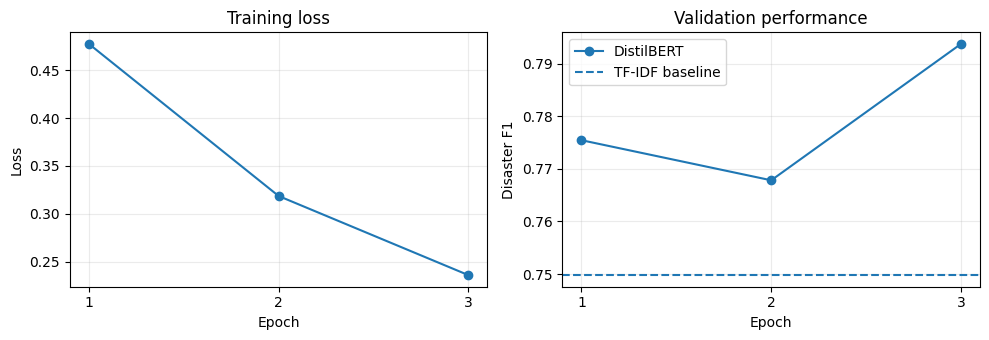

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history_df.index, history_df["training_loss"], marker="o")
axes[0].set(title="Training loss", xlabel="Epoch", ylabel="Loss")

axes[1].plot(
    history_df.index,
    history_df["validation_disaster_f1"],
    marker="o",
    label="DistilBERT",
)
axes[1].axhline(
    baseline_metrics["disaster_f1"],
    linestyle="--",
    label="TF-IDF baseline",
)
axes[1].set(title="Validation performance", xlabel="Epoch", ylabel="Disaster F1")
axes[1].legend()

for axis in axes:
    axis.set_xticks(history_df.index)
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Training loss falls steadily from 0.477 to 0.236. Validation F1 moves from 0.775 to 0.768 and then to 0.794. The training signal is clear, but validation F1 does not improve at every epoch: the lower training loss in epoch 2 comes with a small F1 drop.

The third epoch gives the best disaster F1 and finishes above the TF-IDF baseline of 0.750. DistilBERT benefits from pretraining, but the small changes between epochs also show why we should evaluate checkpoints rather than assume that more optimisation always improves generalisation.


# Stage 4: Evaluate and inspect

Training has produced a classifier, but a single score will not tell us how its behaviour changed. We will move from aggregate metrics to error types, individual mistakes and controlled examples.

## Compare the same metrics on the same rows

In [11]:
transformer_metrics = {
    "accuracy": accuracy_score(true_labels, transformer_prediction),
    "disaster_f1": f1_score(true_labels, transformer_prediction),
}
comparison = pd.DataFrame(
    [baseline_metrics, transformer_metrics],
    index=["TF-IDF + logistic regression", "Fine-tuned DistilBERT"],
)
display(comparison.round(3))


,accuracy,disaster_f1
TF-IDF + logistic regression,0.807,0.750
Fine-tuned DistilBERT,0.830,0.794


On this split, fine-tuned DistilBERT reaches 0.830 accuracy and 0.794 disaster F1. The TF-IDF baseline reaches 0.807 and 0.750 respectively. DistilBERT therefore gains about 2.3 accuracy points and 4.4 F1 points on exactly the same validation rows.

The result supports transfer learning here, but the margin is not enormous. The lexical baseline remains competitive despite being much cheaper to train and run.


## Where do the errors go?

Two models can obtain similar accuracy while making very different mistakes. A confusion matrix separates false alarms from missed disasters, which matters when those errors have different costs.

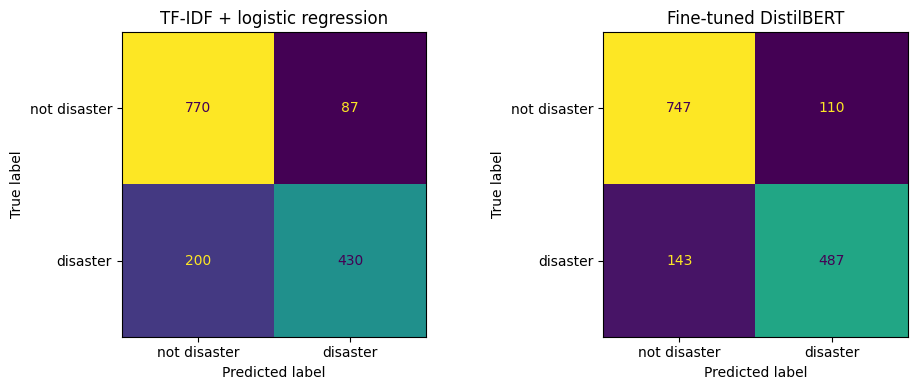

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, name, prediction in [
    (axes[0], "TF-IDF + logistic regression", baseline_prediction),
    (axes[1], "Fine-tuned DistilBERT", transformer_prediction),
]:
    ConfusionMatrixDisplay(
        confusion_matrix(validation_df["target"], prediction),
        display_labels=["not disaster", "disaster"],
    ).plot(ax=axis, colorbar=False, values_format="d")
    axis.set_title(name)
plt.tight_layout()
plt.show()


The baseline misses 200 disasters and raises 87 false alarms. DistilBERT reduces the missed disasters to 143, but false alarms rise to 110.

The F1 improvement therefore comes mainly from higher disaster recall: DistilBERT finds 57 disasters that the lexical baseline misses, at the cost of 23 additional false alarms. Whether that trade-off is desirable depends on the cost of each error in the real application.


## The most confident mistakes

Aggregate metrics tell us how often a model is wrong; individual examples help us understand why. We will inspect the errors for which each model assigned the highest confidence to its incorrect label.

In [13]:
validation_results = validation_df[["text", "target"]].reset_index(drop=True).copy()
validation_results["tfidf_probability"] = baseline_probability
validation_results["tfidf_prediction"] = baseline_prediction
validation_results["distilbert_probability"] = transformer_probability
validation_results["distilbert_prediction"] = transformer_prediction

for model_name, probability_column, prediction_column in [
    ("TF-IDF", "tfidf_probability", "tfidf_prediction"),
    ("DistilBERT", "distilbert_probability", "distilbert_prediction"),
]:
    mistakes = validation_results[
        validation_results[prediction_column] != validation_results["target"]
    ].copy()
    mistakes["confidence_in_wrong_label"] = np.where(
        mistakes[prediction_column].eq(1),
        mistakes[probability_column],
        1 - mistakes[probability_column],
    )
    print()
    print(f"{model_name}: most confident wrong predictions")
    display(
        mistakes.nlargest(4, "confidence_in_wrong_label")[
            ["text", "target", prediction_column, probability_column]
        ].style.format({probability_column: "{:.3f}"})
    )



TF-IDF: most confident wrong predictions


,text,target,tfidf_prediction,tfidf_probability
568,My back is so sunburned :(,1,0,0.070
142,2Leezy its like you're about to fall down a cliff but you're grabbing my hand but my palms are sweaty ... Why bruh? https://t.co/GrWdr4kuf3,1,0,0.081
112,If you're in search of powerful content to improve your business or have been frustrated with the deluge of 'quantitÛ_https://t.co/64cyMG1lTG,1,0,0.088
1423,Just came back from camping and returned with a new song which gets recorded tomorrow. Can't wait! #Desolation #TheConspiracyTheory #NewEP,1,0,0.110



DistilBERT: most confident wrong predictions


,text,target,distilbert_prediction,distilbert_probability
730,DISASTER AVERTED: Police kill gunman with Û÷hoax deviceÛª atåÊcinema http://t.co/5NG0FzpVdS,0,1,0.993
139,Teen Disaster Preparedness Event in Van Nuys August 11 @ 5:30pm http://t.co/fXUX987vZx via @VanNuysCouncil,0,1,0.991
832,'Up to 40% of businesses affected by a natural or man-made disaster never reopen' http://t.co/35JyAp0ul9,0,1,0.991
524,Kosciusko police investigating pedestrian fatality hit by a train Thursday http://t.co/m5djLLxoZP,0,1,0.990


Several high-confidence errors are not obviously model failures. Some tweets describe fictional crashes, quote headlines without context or use labels that are hard to infer from the text alone. Error analysis therefore checks the dataset as well as the model.

The probabilities are ranking scores, not guarantees. A prediction near 0.95 can still be wrong, especially when the annotation rule is ambiguous.

## Five controlled stress cases

These examples are not another test set. They isolate literal disaster language, metaphor, negation, ambiguity and noisy formatting.

In [14]:
stress_cases = pd.DataFrame(
    {
        "case": ["literal", "figurative", "negated", "ambiguous", "noisy"],
        "text": [
            "A wildfire destroyed twelve homes and forced residents to evacuate.",
            "My inbox is on fire after coming back from holiday.",
            "Officials confirmed that the reported explosion did not happen.",
            "What a disaster.",
            "BREAKING!!! FLOOD WARNING http://t.co/example",
        ],
    }
)
stress_cases["tfidf_disaster_probability"] = baseline_model.predict_proba(
    vectorizer.transform(stress_cases["text"])
)[:, 1]

stress_ids, stress_mask = encode_texts(stress_cases["text"])
stress_loader = DataLoader(
    TensorDataset(
        stress_ids,
        stress_mask,
        torch.zeros(len(stress_cases), dtype=torch.long),
    ),
    batch_size=len(stress_cases),
)
stress_cases["distilbert_disaster_probability"] = evaluate_transformer(stress_loader)[0]
display(
    stress_cases.style.format(
        {
            "tfidf_disaster_probability": "{:.3f}",
            "distilbert_disaster_probability": "{:.3f}",
        }
    )
)


,case,text,tfidf_disaster_probability,distilbert_disaster_probability
0,literal,A wildfire destroyed twelve homes and forced residents to evacuate.,0.731,0.991
1,figurative,My inbox is on fire after coming back from holiday.,0.546,0.529
2,negated,Officials confirmed that the reported explosion did not happen.,0.631,0.989
3,ambiguous,What a disaster.,0.599,0.156
4,noisy,BREAKING!!! FLOOD WARNING http://t.co/example,0.708,0.989


DistilBERT gives the literal wildfire a disaster probability of 0.991 and the noisy uppercase flood warning 0.989. Those are the easy successes. The figurative “inbox is on fire” case only falls from 0.546 with TF-IDF to 0.529 with DistilBERT, so both models still classify it as a disaster at the 0.5 threshold.

The negated explosion is the clearest failure: despite “did not happen”, DistilBERT assigns a disaster probability of 0.989. The contextual model improves the average metrics and several controlled cases, but it still relies heavily on salient disaster language and does not handle every compositional cue correctly.

The short “What a disaster” example moves in the opposite direction: TF-IDF gives it 0.599, while DistilBERT gives it 0.156. Without more context, there is no unambiguously correct interpretation, which is exactly why isolated stress cases should be discussed rather than treated as another benchmark.


# Stage 5: Zero-shot classification

The first two models learned from the disaster-tweet labels. Now we remove that supervision completely.

We will use **[google/flan-t5-small](https://huggingface.co/google/flan-t5-small)**, an instruction-tuned model published by Google. It has seen many tasks during instruction tuning, but it will not see any labelled example from this dataset. Zero-shot here means zero disaster-tweet training examples, not a model with zero previous training.

In [15]:
zero_shot_df, _ = train_test_split(
    validation_results,
    train_size=200,
    stratify=validation_results["target"],
    random_state=SEED,
)
zero_shot_df = zero_shot_df.reset_index(drop=True)

print(f"Zero-shot evaluation rows: {len(zero_shot_df)}")
print(f"Disaster share: {zero_shot_df['target'].mean():.1%}")

Zero-shot evaluation rows: 200
Disaster share: 42.5%


FLAN-T5 is slower than the two classifiers because it is a sequence-to-sequence model. We use a fixed stratified sample of 200 validation tweets to keep this stage short. The table below will recompute all three models on those same 200 rows; comparing the zero-shot sample with the full 1,487-row metrics would not be fair.

In [16]:
import torch.nn.functional as functional
from transformers import AutoModelForSeq2SeqLM

zero_shot_model_id = "google/flan-t5-small"
zero_shot_model_revision = "0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab"
zero_shot_tokenizer = AutoTokenizer.from_pretrained(
    zero_shot_model_id, revision=zero_shot_model_revision
)
zero_shot_model = AutoModelForSeq2SeqLM.from_pretrained(
    zero_shot_model_id, revision=zero_shot_model_revision
).to(device)
zero_shot_model.eval()

print(f"Model: {zero_shot_model_id}")
print(f"Parameters: {sum(p.numel() for p in zero_shot_model.parameters()):,}")

Model: google/flan-t5-small
Parameters: 76,961,152


Free generation could return variants such as “real disaster,” “yes” or an explanation. That would mix classification quality with output-format failures. Instead, we score two fixed candidate labels, 0 and 1, under the model and normalise their likelihoods.

The numeric labels have the same token length. This avoids giving “disaster” an accidental advantage over the two-token phrase “not disaster.”

In [17]:
zero_shot_labels = ["0", "1"]

def zero_shot_prompt(tweet):
    return (
        "Classify the tweet. Use label 1 if it reports a real disaster "
        "and label 0 if it does not. Answer with only 0 or 1.\n"
        f"Tweet: {tweet}\nLabel:"
    )


def score_zero_shot_labels(texts, batch_size=32):
    disaster_probabilities = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        prompts = [zero_shot_prompt(text) for text in batch_texts]
        repeated_prompts = [
            prompt
            for prompt in prompts
            for _ in zero_shot_labels
        ]
        candidate_targets = zero_shot_labels * len(prompts)

        inputs = zero_shot_tokenizer(
            repeated_prompts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt",
        ).to(device)
        target_ids = zero_shot_tokenizer(
            text_target=candidate_targets,
            padding=True,
            return_tensors="pt",
        )["input_ids"].to(device)
        labels = target_ids.clone()
        labels[labels == zero_shot_tokenizer.pad_token_id] = -100

        with torch.inference_mode():
            logits = zero_shot_model(**inputs, labels=labels).logits

        token_losses = functional.cross_entropy(
            logits.reshape(-1, logits.shape[-1]),
            labels.reshape(-1),
            reduction="none",
            ignore_index=-100,
        ).reshape(labels.shape)
        valid_tokens = labels.ne(-100)
        sequence_losses = (
            (token_losses * valid_tokens).sum(dim=1)
            / valid_tokens.sum(dim=1)
        )
        label_scores = (-sequence_losses).reshape(
            len(prompts), len(zero_shot_labels)
        )
        disaster_probabilities.extend(
            torch.softmax(label_scores, dim=1)[:, 1].cpu().tolist()
        )

    return np.array(disaster_probabilities)

In [18]:
zero_shot_probability = score_zero_shot_labels(
    zero_shot_df["text"].tolist()
)
zero_shot_prediction = (zero_shot_probability >= 0.5).astype(int)

sample_comparison = pd.DataFrame(
    {
        "accuracy": [
            accuracy_score(zero_shot_df["target"], zero_shot_df["tfidf_prediction"]),
            accuracy_score(zero_shot_df["target"], zero_shot_df["distilbert_prediction"]),
            accuracy_score(zero_shot_df["target"], zero_shot_prediction),
        ],
        "disaster_f1": [
            f1_score(zero_shot_df["target"], zero_shot_df["tfidf_prediction"]),
            f1_score(zero_shot_df["target"], zero_shot_df["distilbert_prediction"]),
            f1_score(zero_shot_df["target"], zero_shot_prediction),
        ],
    },
    index=[
        "TF-IDF + logistic regression",
        "Fine-tuned DistilBERT",
        "Zero-shot Google FLAN-T5 Small",
    ],
)
display(sample_comparison.round(3))
print(
    "Zero-shot disaster-score range: "
    f"{zero_shot_probability.min():.3f} to {zero_shot_probability.max():.3f}"
)


,accuracy,disaster_f1
TF-IDF + logistic regression,0.755,0.684
Fine-tuned DistilBERT,0.805,0.766
Zero-shot Google FLAN-T5 Small,0.560,0.516


Zero-shot disaster-score range: 0.458 to 0.543


The zero-shot model reaches about 0.56 accuracy and 0.52 disaster F1 on this sample, well below both supervised models. Its scores occupy a very narrow interval around 0.5, from roughly 0.46 to 0.54. Small changes to the prompt or threshold can therefore flip many predictions.

Zero-shot removes task-specific training, not the need for evaluation. It is useful when labelled data or training time is unavailable, but that convenience has a measurable cost here.

In [19]:
zero_shot_confusion = confusion_matrix(
    zero_shot_df["target"], zero_shot_prediction
)
display(
    pd.DataFrame(
        zero_shot_confusion,
        index=["actual not disaster", "actual disaster"],
        columns=["predicted not disaster", "predicted disaster"],
    )
)

stress_cases["flan_zero_shot_probability"] = score_zero_shot_labels(
    stress_cases["text"].tolist()
)
display(
    stress_cases[
        [
            "case",
            "tfidf_disaster_probability",
            "distilbert_disaster_probability",
            "flan_zero_shot_probability",
        ]
    ].style.format(
        {
            "tfidf_disaster_probability": "{:.3f}",
            "distilbert_disaster_probability": "{:.3f}",
            "flan_zero_shot_probability": "{:.3f}",
        }
    )
)


,predicted not disaster,predicted disaster
actual not disaster,65,50
actual disaster,38,47


,case,tfidf_disaster_probability,distilbert_disaster_probability,flan_zero_shot_probability
0,literal,0.731,0.991,0.465
1,figurative,0.546,0.529,0.472
2,negated,0.631,0.989,0.469
3,ambiguous,0.599,0.156,0.499
4,noisy,0.708,0.989,0.492


The confusion matrix contains substantial error in both directions: 50 false alarms and 38 missed disasters. On the controlled cases, the zero-shot scores again cluster near 0.5 and barely separate a literal wildfire from a figurative fire or a negated explosion.

The comparison now has three distinct forms of learning: TF-IDF learns only from this dataset, DistilBERT transfers pretrained representations and then learns from the disaster labels, and FLAN-T5 transfers instruction-following behaviour without seeing those labels.


# Stage 6: Try a GPT model online

The previous models run inside the notebook. A hosted GPT model gives us a fourth route: send the text and instructions to an API and receive a prediction without downloading or fine-tuning the model. This cell uses the same five synthetic stress cases, so no rows from the dataset are uploaded.

The example follows the current OpenAI **[Responses API quickstart](https://developers.openai.com/api/docs/quickstart)** and uses [`gpt-5.6-luna`](https://developers.openai.com/api/docs/models), the cost-sensitive GPT-5.6 model. It is disabled by default because it needs an internet connection, an OpenAI API key and API credit. Set the flag to `True`; the key is requested with hidden input and is never written into the notebook. The model name is kept in one variable because hosted model availability changes over time.

In [20]:
# @title Optional online GPT comparison
RUN_OPENAI_EXAMPLE = False
ONLINE_MODEL = "gpt-5.6-luna"

if RUN_OPENAI_EXAMPLE:
    import json
    import os
    from getpass import getpass

    from openai import OpenAI

    if not os.environ.get("OPENAI_API_KEY"):
        os.environ["OPENAI_API_KEY"] = getpass("OpenAI API key: ")

    client = OpenAI()
    cases_for_api = stress_cases[["case", "text"]].to_dict(orient="records")
    response = client.responses.create(
        model=ONLINE_MODEL,
        instructions=(
            "Classify short English texts. Use 'disaster' only when the text "
            "reports a real dangerous event; otherwise use 'not disaster'."
        ),
        input=(
            "Classify these cases. Return a compact Markdown table with columns "
            "case, label and short reason. The label must be exactly 'disaster' "
            "or 'not disaster'.\n\n"
            + json.dumps(cases_for_api, indent=2)
        ),
    )
    print(response.output_text)
else:
    print("Online example skipped. Set RUN_OPENAI_EXAMPLE = True to call the API.")

Online example skipped. Set RUN_OPENAI_EXAMPLE = True to call the API.


This output should be read as a live demonstration, not inserted into the fixed benchmark above. A hosted model can change, and the answer can also change with the prompt. To make it a proper experiment we would fix a model snapshot if available, classify the same labelled validation sample and calculate the same accuracy, F1 score and confusion matrix. The short reasons are still useful in class: they reveal whether the model noticed negation, figurative language and quoted text rather than merely producing the expected label.

In [21]:
# @title Consistency checks
assert len(training_df) == 7_613
assert duplicate_after_first == 110
assert repeated_mask.sum() == 179
assert conflicting_texts == 18
assert len(model_df) == 7_434
assert set(train_df["text"]).isdisjoint(set(validation_df["text"]))
assert model_id == "distilbert/distilbert-base-uncased"
assert 0.70 < baseline_metrics["disaster_f1"] < 0.85
assert classical_comparison["disaster_f1"].idxmax() == "Logistic regression"
assert history_df.index.tolist() == [1, 2, 3]
assert history_df.loc[3, "validation_disaster_f1"] == history_df["validation_disaster_f1"].max()
assert transformer_metrics["disaster_f1"] > baseline_metrics["disaster_f1"]
assert len(stress_cases) == 5
assert stress_cases.loc[stress_cases["case"].eq("negated"), "distilbert_disaster_probability"].iloc[0] > 0.90
assert len(zero_shot_df) == 200
assert zero_shot_probability.shape == (200,)
assert 0.45 < zero_shot_probability.min() < 0.50
assert 0.50 < zero_shot_probability.max() < 0.56
print("Checks passed: notebook text and outputs are consistent.")


Checks passed: notebook text and outputs are consistent.


# Takeaway

- Remove leakage and annotation conflicts before comparing models.
- Keep the split and metrics fixed; otherwise the comparison says very little.
- DistilBERT beats the TF-IDF baseline on this split, but the lexical model remains competitive for a fraction of the training cost.
- The F1 gain comes mainly from finding more disasters, with a smaller increase in false alarms.
- Pretraining is a starting point. Fine-tuning still depends on data, optimisation and the errors that matter to the application.
- Better aggregate metrics do not eliminate simple failures: the negated explosion remains a confident mistake.
- Zero-shot classification removes task-specific training, but not the need for a labelled evaluation set.
- A hosted GPT model is easy to call, but cost, changing model versions and prompt sensitivity must be part of the comparison.
- Metrics, confusion matrices, real errors and controlled stress cases answer different questions.

## Things to try

- Freeze the DistilBERT encoder and train only the classifier head; compare runtime and validation F1.
- Move the decision threshold away from 0.5 and decide which trade-off between missed disasters and false alarms you would accept.
- Rewrite the zero-shot instruction or candidate labels and check how stable the FLAN-T5 scores are.
